# 02 · KPIs & Operational Insights

Designs and visualizes the key performance indicators of the delivery operation at three levels:

- **City** — On-Time Success Rate, Hyper-Delay Rate, Fleet Load, Avg Dispatch Wait, Pre-Transit Ratio
- **Store** — prep-time efficiency, hyper-delay contribution, reliability (cancel vs. return)
- **Courier (biker)** — speed, productivity, success rate, late-sync behavior (*Forgetful Index*)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the cleaned operational data
df = pd.read_csv('../data/operational_data_clean.csv')

## Imputation

Remaining gaps are filled conservatively: median for queue time, store-level (then city-level) means for prep time and distance.

In [4]:
# missing values
# Dispatch Wait (Median Imputation)
df['Dispatch_Wait_Time'] = df['Dispatch_Wait_Time'].fillna(df['Dispatch_Wait_Time'].median())

# Vendor Prep Time (Store Mean)
df['At_Vendor_Prep_Time'] = df['At_Vendor_Prep_Time'].fillna(
    df.groupby('StoreID')['At_Vendor_Prep_Time'].transform('mean')
)
df['At_Vendor_Prep_Time'] = df['At_Vendor_Prep_Time'].fillna(
    df.groupby('City')['At_Vendor_Prep_Time'].transform('mean')
)

# Distance (Store Mean Imputation)
df['Distance_V2C'] = df['Distance_V2C'].fillna(
    df.groupby('StoreID')['Distance_V2C'].transform('mean')
)

## Performance segments

Orders are bucketed against the 40-minute business SLA: **On-Time** (≤ 40), **Delayed** (40–60), **Hyper-Delay** (> 60).

In [5]:
# Labels: On-Time (<=40), Delayed (40-60), Hyper-Delay (>60)
def get_performance_label(t):
    if pd.isna(t): return 'N/A'
    if t <= 40: return 'On-Time'
    if t <= 60: return 'Delayed'
    return 'Hyper-Delay'

df['Performance_Segment'] = df['Total_Cycle_Time'].apply(get_performance_label)

## City-level KPIs

In [6]:
# City KPI 
city_kpi = df.groupby('City').agg(
    Total_Orders=('OrderID', 'count'),
    On_Time_Count=('Performance_Segment', lambda x: (x == 'On-Time').sum()),
    Hyper_Delay_Count=('Performance_Segment', lambda x: (x == 'Hyper-Delay').sum()),
    Avg_Dispatch_Wait=('Dispatch_Wait_Time', 'mean'),
    Avg_Prep_Time=('At_Vendor_Prep_Time', 'mean'),
    Avg_Total_Time=('Total_Cycle_Time', 'mean'),
    Active_Bikers=('DriverID', 'nunique')
).reset_index()


city_kpi['Success_Rate_(%)'] = (city_kpi['On_Time_Count'] / city_kpi['Total_Orders']) * 100
city_kpi['Hyper_Delay_Rate_(%)'] = (city_kpi['Hyper_Delay_Count'] / city_kpi['Total_Orders']) * 100
city_kpi['Fleet_Load'] = city_kpi['Total_Orders'] / city_kpi['Active_Bikers']
city_kpi['Pre_Transit_Ratio'] = (city_kpi['Avg_Dispatch_Wait'] + city_kpi['Avg_Prep_Time']) / city_kpi['Avg_Total_Time']


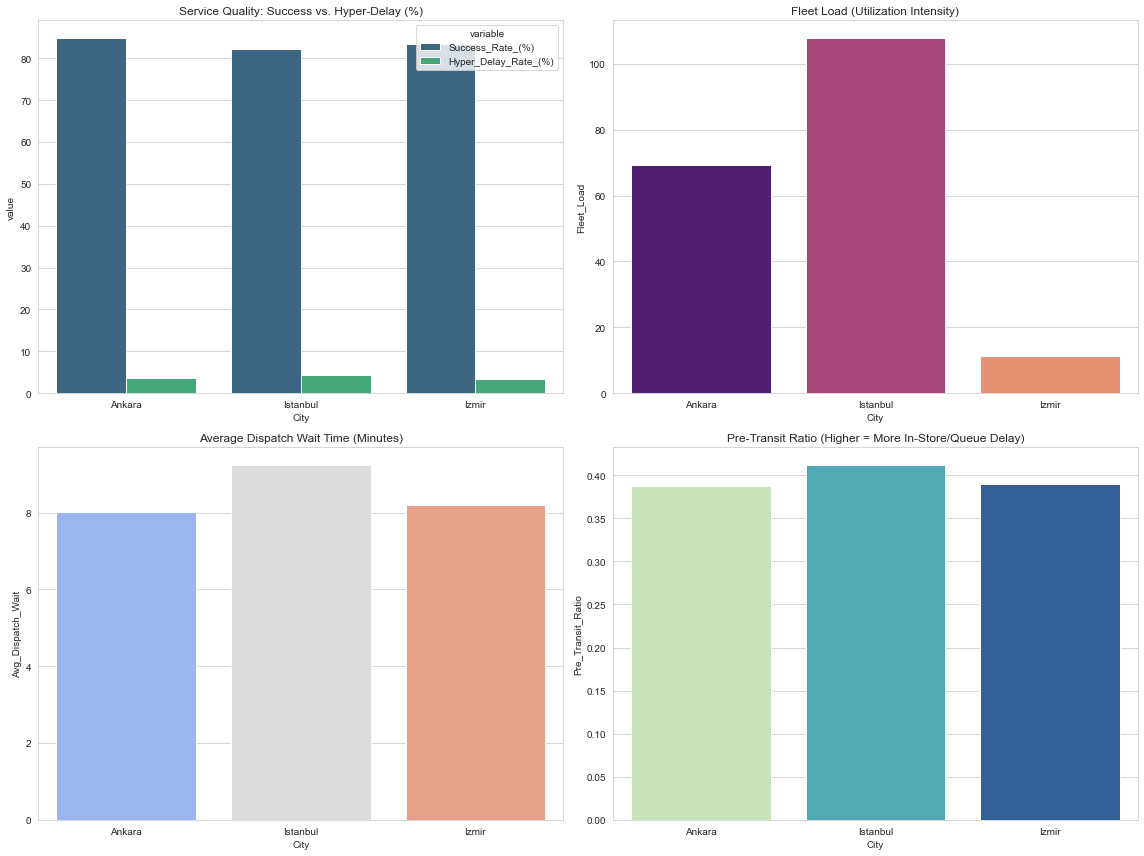

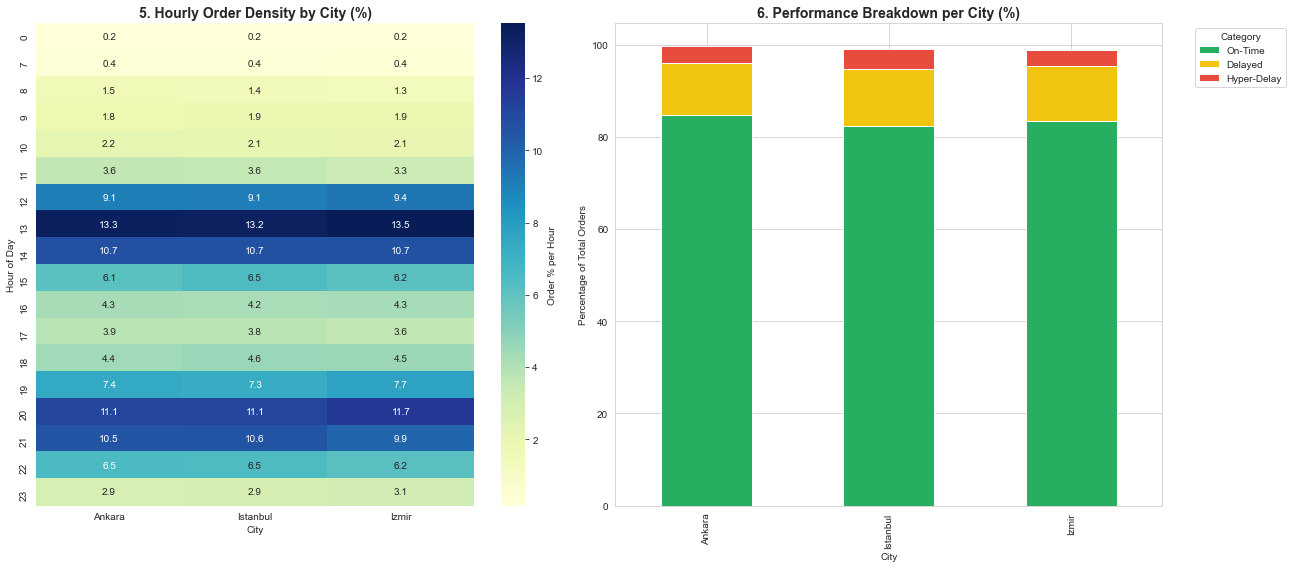

In [7]:
sns.set_style("whitegrid")

# --- Figure A: City KPI panel (2x2) ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Graph 1: Service Quality (Success vs Hyper-Delay)
kpi_melt = city_kpi.melt(id_vars='City', value_vars=['Success_Rate_(%)', 'Hyper_Delay_Rate_(%)'])
sns.barplot(data=kpi_melt, x='City', y='value', hue='variable', palette='viridis', ax=axes[0, 0])
axes[0, 0].set_title('Service Quality: Success vs. Hyper-Delay (%)')

# Graph 2: Fleet Load (Orders per Biker)
sns.barplot(data=city_kpi, x='City', y='Fleet_Load', palette='magma', ax=axes[0, 1])
axes[0, 1].set_title('Fleet Load (Utilization Intensity)')

# Graph 3: Bottleneck Identification (Avg Dispatch Wait)
sns.barplot(data=city_kpi, x='City', y='Avg_Dispatch_Wait', palette='coolwarm', ax=axes[1, 0])
axes[1, 0].set_title('Average Dispatch Wait Time (Minutes)')

# Graph 4: Operational Efficiency (Pre-Transit Ratio)
sns.barplot(data=city_kpi, x='City', y='Pre_Transit_Ratio', palette='YlGnBu', ax=axes[1, 1])
axes[1, 1].set_title('Pre-Transit Ratio (Higher = More In-Store/Queue Delay)')

plt.tight_layout()
plt.savefig('city_performance_kpis.png')
plt.show()

# --- Figure B: Demand density & performance breakdown (1x2) ---
heatmap_data = pd.crosstab(df['Order_Hour'], df['City'], normalize='columns') * 100
breakdown_data = pd.crosstab(df['City'], df['Performance_Segment'], normalize='index') * 100
cols = [c for c in ['On-Time', 'Delayed', 'Hyper-Delay'] if c in breakdown_data.columns]
breakdown_data = breakdown_data[cols]

fig2, axes2 = plt.subplots(1, 2, figsize=(18, 8))

# Graph 5: Order Density Heatmap (City vs Hour)
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap='YlGnBu', ax=axes2[0], cbar_kws={'label': 'Order % per Hour'})
axes2[0].set_title('5. Hourly Order Density by City (%)', fontsize=14, fontweight='bold')
axes2[0].set_xlabel('City')
axes2[0].set_ylabel('Hour of Day')

# Graph 6: Performance Breakdown (Stacked Bar)
breakdown_data.plot(kind='bar', stacked=True, ax=axes2[1], color=['#27ae60', '#f1c40f', '#e74c3c'])
axes2[1].set_title('6. Performance Breakdown per City (%)', fontsize=14, fontweight='bold')
axes2[1].set_ylabel('Percentage of Total Orders')
axes2[1].legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('full_operational_dashboard.png')
plt.show()


## Store-level KPIs

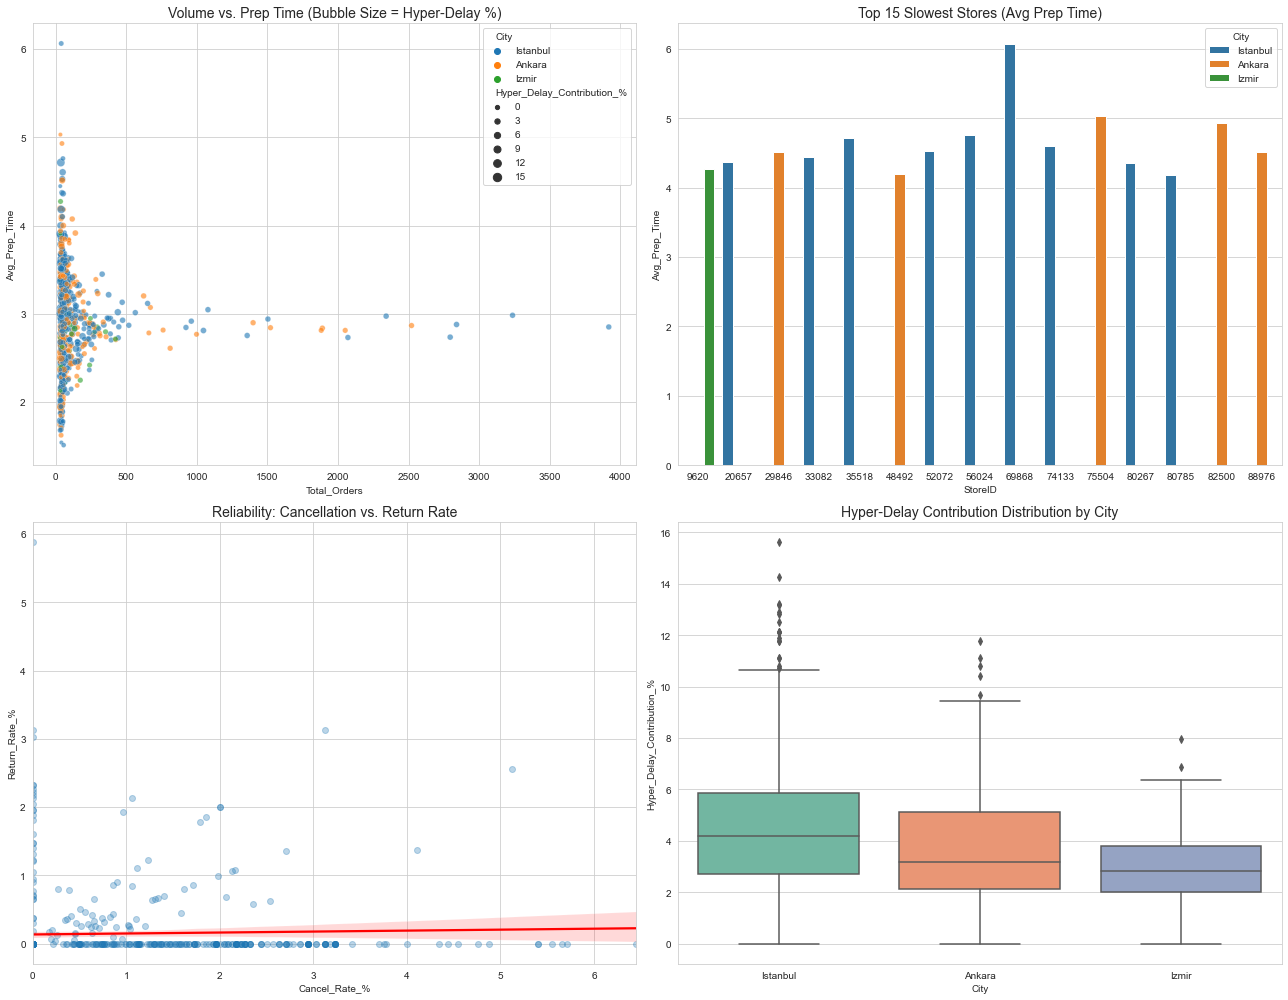

In [8]:
df['At_Vendor_Prep_Time'] = df['At_Vendor_Prep_Time'].fillna(
    df.groupby('StoreID')['At_Vendor_Prep_Time'].transform('mean')
)
df['At_Vendor_Prep_Time'] = df['At_Vendor_Prep_Time'].fillna(
    df.groupby('City')['At_Vendor_Prep_Time'].transform('mean')
)

store_stats = df.groupby(['StoreID', 'City']).agg(
    Total_Orders=('OrderID', 'count'),
    Avg_Prep_Time=('At_Vendor_Prep_Time', 'mean'),
    Hyper_Delay_Count=('Performance_Segment', lambda x: (x == 'Hyper-Delay').sum()),
    Return_Count=('Final_Status', lambda x: (x == 'Returned').sum()),
    Cancel_Count=('Final_Status', lambda x: (x == 'Canceled').sum())
).reset_index()

store_stats['Return_Rate_%'] = (store_stats['Return_Count'] / store_stats['Total_Orders']) * 100
store_stats['Cancel_Rate_%'] = (store_stats['Cancel_Count'] / store_stats['Total_Orders']) * 100
store_stats['Hyper_Delay_Contribution_%'] = (store_stats['Hyper_Delay_Count'] / store_stats['Total_Orders']) * 100

active_stores = store_stats[store_stats['Total_Orders'] > 30].copy()

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
sns.set_style("whitegrid")

sns.scatterplot(data=active_stores, x='Total_Orders', y='Avg_Prep_Time', 
                hue='City', size='Hyper_Delay_Contribution_%', alpha=0.6, ax=axes[0,0])
axes[0,0].set_title('Volume vs. Prep Time (Bubble Size = Hyper-Delay %)', fontsize=14)

top_slow_stores = active_stores.sort_values('Avg_Prep_Time', ascending=False).head(15)
sns.barplot(data=top_slow_stores, x='StoreID', y='Avg_Prep_Time', hue='City', ax=axes[0,1])
axes[0,1].set_title('Top 15 Slowest Stores (Avg Prep Time)', fontsize=14)

sns.regplot(data=active_stores, x='Cancel_Rate_%', y='Return_Rate_%', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'}, ax=axes[1,0])
axes[1,0].set_title('Reliability: Cancellation vs. Return Rate', fontsize=14)

sns.boxplot(data=active_stores, x='City', y='Hyper_Delay_Contribution_%', palette='Set2', ax=axes[1,1])
axes[1,1].set_title('Hyper-Delay Contribution Distribution by City', fontsize=14)

plt.tight_layout()
plt.savefig('store_kpi_analysis.png')
plt.show()


## Courier-level KPIs

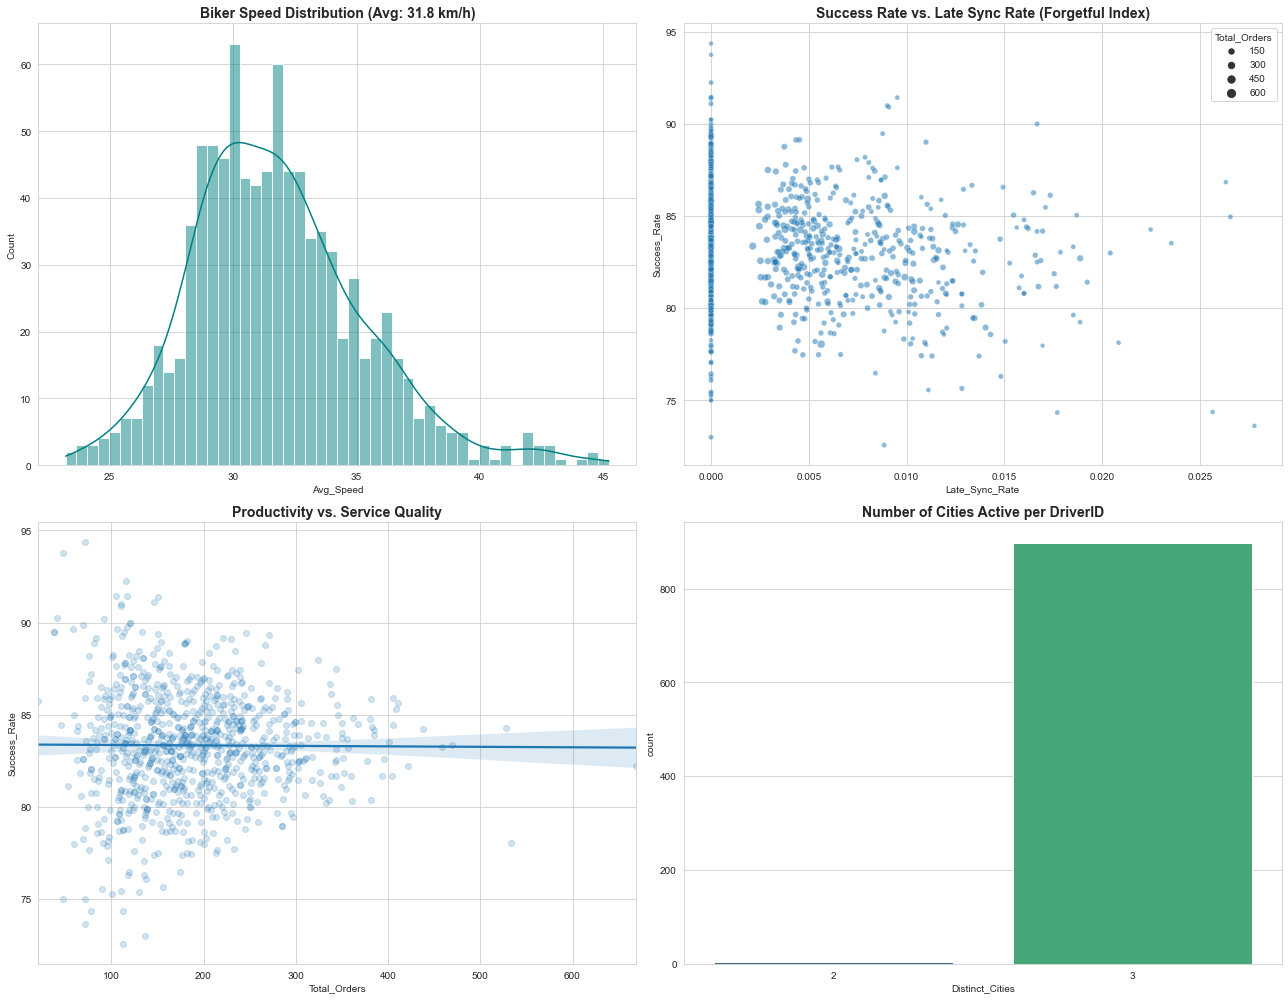

In [9]:

# Imputation for Biker Analysis
df['Dispatch_Wait_Time'] = df['Dispatch_Wait_Time'].fillna(df['Dispatch_Wait_Time'].median())
df['Distance_V2C'] = df['Distance_V2C'].fillna(df.groupby('StoreID')['Distance_V2C'].transform('mean'))
df['At_Vendor_Prep_Time'] = df['At_Vendor_Prep_Time'].fillna(df.groupby('StoreID')['At_Vendor_Prep_Time'].transform('mean'))

# Speed calculation (km/h)
df['Biker_Speed'] = (df['Distance_V2C'] / 1000) / (df['Transit_To_Customer_Time'] / 60)
df['Biker_Speed'] = df['Biker_Speed'].replace([np.inf, -np.inf], np.nan)

# Forgetful Index (Anomaly calculation: Orders closed after 180 mins or with high residual time)
df['Residual_Time'] = df['Total_Cycle_Time'] - (df['Dispatch_Wait_Time'] + df['Travel_To_Vendor_Time'] + df['At_Vendor_Prep_Time'] + df['Transit_To_Customer_Time'])
df['Is_Late_Sync'] = (df['Total_Cycle_Time'] > 120) | (df['Residual_Time'] > 30)

biker_kpi = df.groupby('DriverID').agg(
    Total_Orders=('OrderID', 'count'),
    Avg_Speed=('Biker_Speed', 'mean'),
    Success_Rate=('Performance_Segment', lambda x: (x == 'On-Time').sum() / len(x) * 100),
    Late_Sync_Rate=('Is_Late_Sync', 'mean'),
    Distinct_Cities=('City', 'nunique')
).reset_index()

# 5. Visualizations
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
sns.set_style("whitegrid")

# Graph 1: Speed Distribution
sns.histplot(biker_kpi['Avg_Speed'].dropna(), bins=50, kde=True, color='teal', ax=axes[0,0])
axes[0,0].set_title(f'Biker Speed Distribution (Avg: {biker_kpi["Avg_Speed"].mean():.1f} km/h)', fontsize=14, fontweight='bold')

# Graph 2: Success Rate vs. Late Sync (Forgetful Index)
sns.scatterplot(data=biker_kpi, x='Late_Sync_Rate', y='Success_Rate', size='Total_Orders', alpha=0.5, ax=axes[0,1])
axes[0,1].set_title('Success Rate vs. Late Sync Rate (Forgetful Index)', fontsize=14, fontweight='bold')

# Graph 3: Productivity vs. Success
sns.regplot(data=biker_kpi, x='Total_Orders', y='Success_Rate', scatter_kws={'alpha':0.2}, ax=axes[1,0])
axes[1,0].set_title('Productivity vs. Service Quality', fontsize=14, fontweight='bold')

# Graph 4: Cross-City Activity Proof
sns.countplot(x=biker_kpi['Distinct_Cities'], palette='viridis', ax=axes[1,1])
axes[1,1].set_title('Number of Cities Active per DriverID', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('biker_performance_dashboard.png')
plt.show()
